# Restaurant Review & Lingusitic Features Analytics

# load data

In [63]:
import os
import pandas as pd

# Read raw data
master_dir = os.path.dirname(os.getcwd())

# Google
file_dataset = os.path.join(master_dir, "txsa part b",
                           "dataset",
                           "GoogleReview_data_mix.csv")

review_df = pd.read_csv(file_dataset)

In [64]:
review_df.head(10)

,Author,Rating,Review,Restaurant,Location
0,Jia Pin Lee,4,Came here for the High Tea. Great service espe...,Cuisines Restaurant,Ipoh
1,Chui Yi Lum,2,"5 stars for the service, even though some of t...",Cuisines Restaurant,Ipoh
2,liezel wong,1,"Hi, thank you for your service. But! i feel so...",Cuisines Restaurant,Ipoh
3,Nazri Nor,1,I have the worse buffer dinner ever so far. Th...,Cuisines Restaurant,Ipoh
4,Fakru Imran's Channel,5,"That's are Known 5 Elmark "" 9H72 "" & KDK "" 3 K...",Cuisines Restaurant,Ipoh
5,Shukri Said,2,I just came back from there. 2 adults and 4 yo...,Cuisines Restaurant,Ipoh
6,Yosuke,2,Restaurant looks nice but taste is bad. I had ...,Cuisines Restaurant,Ipoh
7,Hadie Rahman,4,"Pros: ambience is great with lake view, good a...",Cuisines Restaurant,Ipoh
8,Abdul Qavi Mohammed,1,We went to this place after reviews on Tripadv...,Cuisines Restaurant,Ipoh
9,BingYao Li,4,"the restaurant is located inside the hotel, th...",Cuisines Restaurant,Ipoh


In [65]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222020 entries, 0 to 222019
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Author      222020 non-null  object
 1   Rating      222020 non-null  int64 
 2   Review      222020 non-null  object
 3   Restaurant  222020 non-null  object
 4   Location    222020 non-null  object
dtypes: int64(1), object(4)
memory usage: 8.5+ MB


# preprocessing

In [66]:
df_ori = review_df.copy()

In [67]:
# number of records
sampleNum = review_df.index.size
print(f"Sample Number: {sampleNum}")

Sample Number: 222020


In [68]:
# number of restaurants
uniqueRestaurants = review_df['Restaurant'].unique().size
print(f"Unique Restaurants: {uniqueRestaurants}")

Unique Restaurants: 1322


In [69]:
# Subset wanted columns
review_df = review_df[['Review', 'Rating']]
review_df.drop_duplicates(inplace=True)
review_df.reset_index(drop=True, inplace=True)

In [70]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201393 entries, 0 to 201392
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Review  201393 non-null  object
 1   Rating  201393 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.1+ MB


In [71]:
# Adding labels
def labelFunc(x):
    if int(x) > 3:
        return "Positive"
    elif int(x) < 3:
        return "Negative"
    elif int(x) == 3:
        return "Neutral"

# Add sentiment label
df_ori["Label"] = df_ori["Rating"].apply(labelFunc)

In [72]:
df_ori.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222020 entries, 0 to 222019
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Author      222020 non-null  object
 1   Rating      222020 non-null  int64 
 2   Review      222020 non-null  object
 3   Restaurant  222020 non-null  object
 4   Location    222020 non-null  object
 5   Label       222020 non-null  object
dtypes: int64(1), object(5)
memory usage: 10.2+ MB


# Exploratory Data Analysis (EDA)

## data distribution

### distribution across different location

In [73]:
df_ori["Location"].value_counts()

Location
Petaling Jaya    48628
Penang           31826
JB               27670
KL               27382
Ipoh             24506
Kuching          21700
Langkawi         18011
Melaka           13682
Miri              6746
Shah Alam         1869
Name: count, dtype: int64

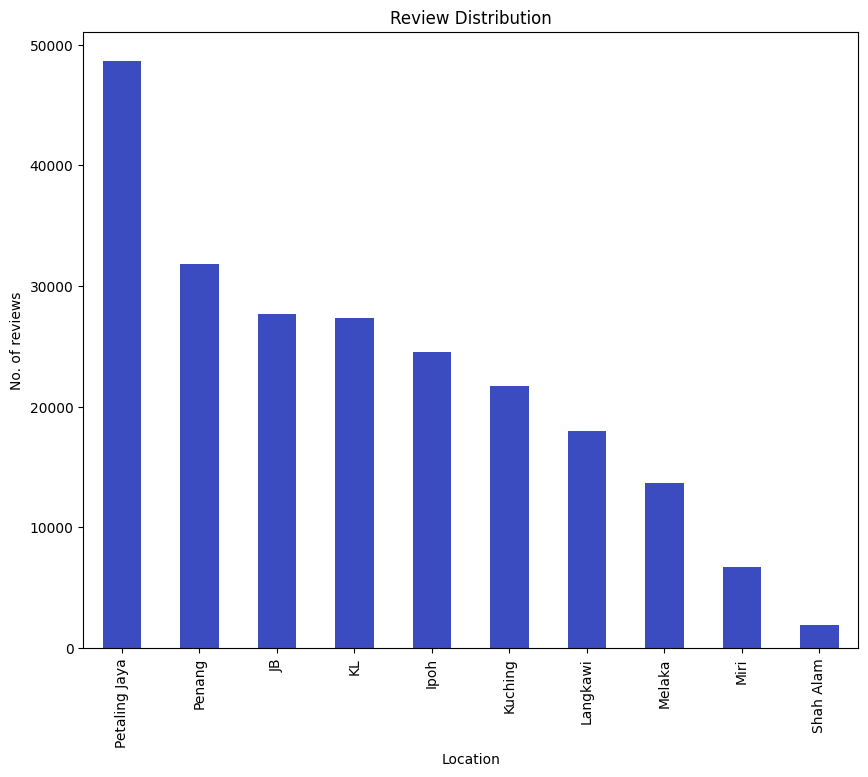

In [74]:
df_ori["Location"].value_counts().plot(kind='bar',
                                       figsize=(10, 8),
                                       ylabel="No. of reviews",
                                       title="Review Distribution",
                                       cmap='coolwarm',
                                      );

highest on review at Petaling Jaya, lowest at Shah Alam.

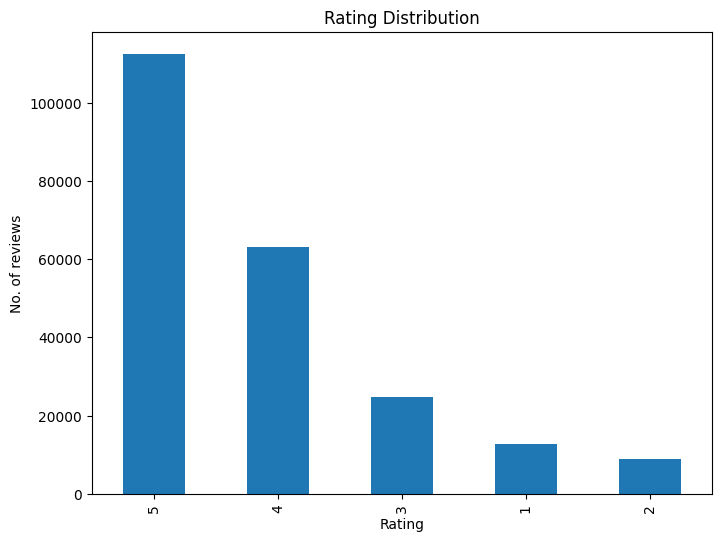

In [75]:
# Rating Distribution
df_ori["Rating"].value_counts().plot(kind='bar',
                                     figsize=(8, 6),
                                     ylabel="No. of reviews",
                                    title="Rating Distribution");

In [76]:
# Average Rating
avgRating = df_ori["Rating"].mean().round(2)
print(f"Average Rating: {avgRating}")

Average Rating: 4.14


Rating skewed towards the high (Positive sentiment) side, as the average rating is 4.14.

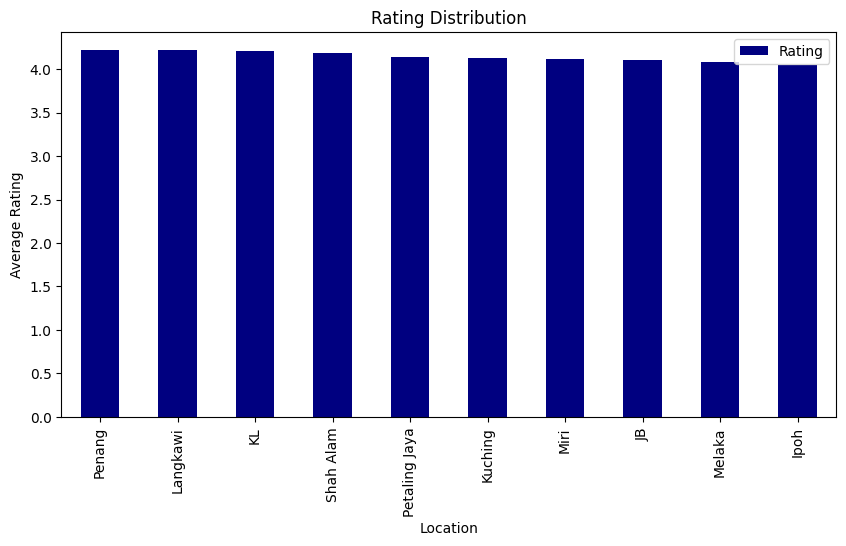

In [77]:
# Average rating across different locations

df_ori.pivot_table(index='Location', values='Rating', aggfunc='mean') \
    .sort_values('Rating', ascending=False) \
    .plot(kind='bar', ylabel="Average Rating",
          title="Rating Distribution", figsize=(10, 5), cmap='jet'
         );

Penang on average has the highest average review rating, whereas the lowest is Ipoh.

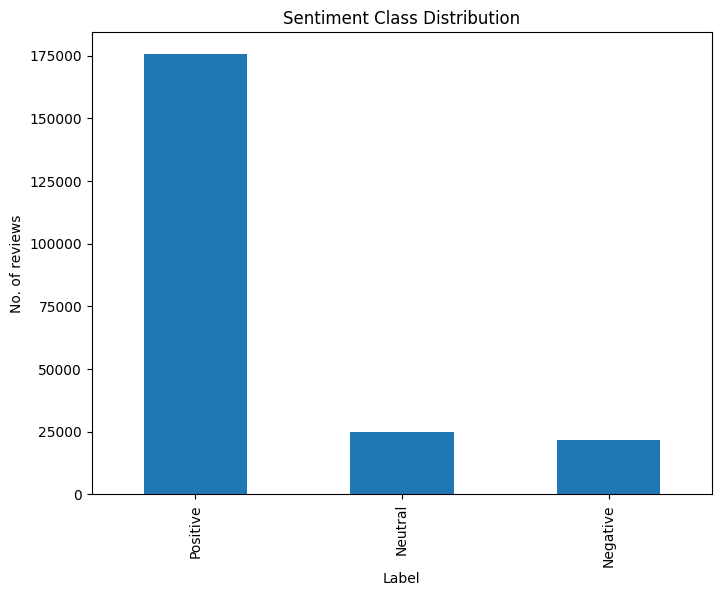

In [78]:
df_ori["Label"].value_counts().plot(kind='bar',
                                     figsize=(8, 6),
                                     ylabel="No. of reviews",
                                    title="Sentiment Class Distribution");

In [79]:
# Proportion of sentiment type
pd.DataFrame(df_ori["Label"].value_counts() / df_ori.index.size * 100) \
    .rename(columns={'Label': "Percentage"})

,count
Label,
Positive,79.106837
Neutral,11.134132
Negative,9.759031


79.1% of the reviews are positive reviews, whereas neutral reviews have 11.1% and negative reviews have 9.8%

In [80]:
averageRating_restaurants = df_ori[["Restaurant", "Rating"]] \
                .pivot_table(index=['Restaurant'], values='Rating', aggfunc='mean') \
                .sort_values('Rating', ascending=False)
averageRating_restaurants.head(10)

,Rating
Restaurant,
NS BURGER,5.0
Guan Guan Restoran,5.0
Potters Place Cafe,5.0
Langkawi Chill Out Cafe Sedapbaq(Travel Agency & cafe),5.0
Celebrity Cafe,5.0
Top Ten Sport Bistro,5.0
Zest Restaurant at Miri Marriott Resort & Spa,5.0
Nasi Kukus Tepi Jalan,5.0
Thirty8 Fashion,5.0


#### Top restaurants : Combined scoring for reviews count and rating, using sum of rating

In [81]:
# get the frequency of each restaurant
restaurant_reviewcount = pd.DataFrame(df_ori["Restaurant"].value_counts())
restaurant_reviewcount = restaurant_reviewcount.reset_index().rename(columns={'index': "Restaurant", 'Restaurant': 'Restaurant', 'count':'Count'})

In [82]:
# sort by review count first, then average rating
overall_toprestaurants = averageRating_restaurants.reset_index().merge(restaurant_reviewcount, on='Restaurant').sort_values(by=['Count', 'Rating'], ascending=False).head(10)
overall_toprestaurants

,Restaurant,Rating,Count
258,Khan’s Indian Cuisine,4.429253,1887
913,Plan B (Ipoh),3.982971,1057
614,Miker Food,4.177177,999
1071,Ming Court Hong Kong Dim Sum 明阁香港点心,3.817818,999
268,Restoran Kacang Pool Haji,4.422805,991
681,Pak Putra Restaurant,4.142424,990
98,Antipodean Cafe,4.641700,988
109,Antipodean @ Atria,4.611740,971
385,Topspot Food Court,4.329876,964
157,Canopy Lounge Rooftop Bar KL,4.551688,948


In [83]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(x=overall_toprestaurants['Restaurant'], 
               y=overall_toprestaurants['Rating'], name="Rating", mode="lines"),
    secondary_y=True
)

fig.add_trace(
    go.Bar(x=overall_toprestaurants['Restaurant'],
           y=overall_toprestaurants['Count'], name="Review Count"),
    secondary_y=False
)

fig.update_xaxes(title_text="Review Count")

# Set y-axes titles
fig.update_yaxes(title_text="Review Count", secondary_y=False)
fig.update_yaxes(title_text="Rating", secondary_y=True)

fig.show()

### relationship between review length and rating

In [84]:
import nltk

tokenizer = nltk.RegexpTokenizer(r"\w+")

df_ori['Word_count'] = df_ori['Review'].apply(lambda x: len(tokenizer.tokenize(x)))

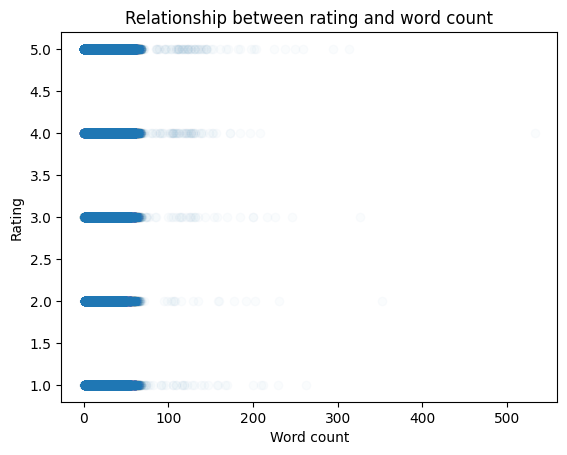

In [85]:
import matplotlib.pyplot as plt

plt.scatter(x=df_ori['Word_count'], y=df_ori['Rating'], alpha=0.02)
plt.xlabel('Word count')
plt.ylabel('Rating')
plt.title('Relationship between rating and word count');

In [86]:
df_ori[['Word_count', 'Rating']].corr()

,Word_count,Rating
Word_count,1.000000,-0.153498
Rating,-0.153498,1.000000


No direct correlationship can be observed. Only slightly negatively correlated, in which longer review tends to be lower rating. user will write long review to rant on something

# Linguistic Features Analytics

In [87]:
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt

stopwordz = set(stopwords.words("English"))
stopwordz.remove('not') # remove negative

In [88]:
#update stopword to include malay
malay_stops = {
    # Pronouns & People
    'saya', 'kami', 'kita', 'mereka', 'dia', 'awak', 'kamu', 'ia', 'anda',
    
    # Prepositions & Connectives
    'yang', 'di', 'dan', 'ke', 'dari', 'pada', 'untuk', 'dengan', 'atau', 
    'serta', 'kerana', 'sebab', 'oleh', 'maka', 'hingga', 'sampai', 'tentang',
    
    # Demonstratives & Particles (Formal + Informal Slang)
    'ini', 'itu', 'ni', 'tu', 'lah', 'je', 'ja', 'jua', 'pun', 'ke', 'kan',
    
    # Verbs / Auxiliaries of Existence & Time
    'ada', 'adalah', 'ialah', 'telah', 'sudah', 'akan', 'pernah', 'sedang',
    'masih', 'boleh', 'dapat', 'hendak', 'mahu', 'nak', 'jadi',
    
    # High-Frequency Fillers
    'banyak', 'sangat', 'agak', 'amat', 'lagi', 'pula', 'seperti', 'paling'
}

# Combine them into a single set
bilingual_stopwords = list(stopwordz.union(malay_stops))

In [89]:
# Unigram
# overall
texts = " ".join(review.lower() for review in review_df["Review"])
# remove punctuation
tokenizer = nltk.RegexpTokenizer(r"\w+")
tokens = tokenizer.tokenize(texts)
# remove stopwords
tokens = [token for token in tokens if token not in bilingual_stopwords]

overall_unigram = nltk.FreqDist(tokens).most_common(20)

In [90]:
overall_unigram
overallUnigram_df = pd.DataFrame(overall_unigram, columns=['Unigram', 'Count'])
overallUnigram_df

,Unigram,Count
0,food,93895
1,good,65926
2,nice,35625
3,place,35424
4,service,31622
5,not,28864
6,great,28271
7,delicious,21616
8,price,19263
9,best,17355


### Overall WordCloud

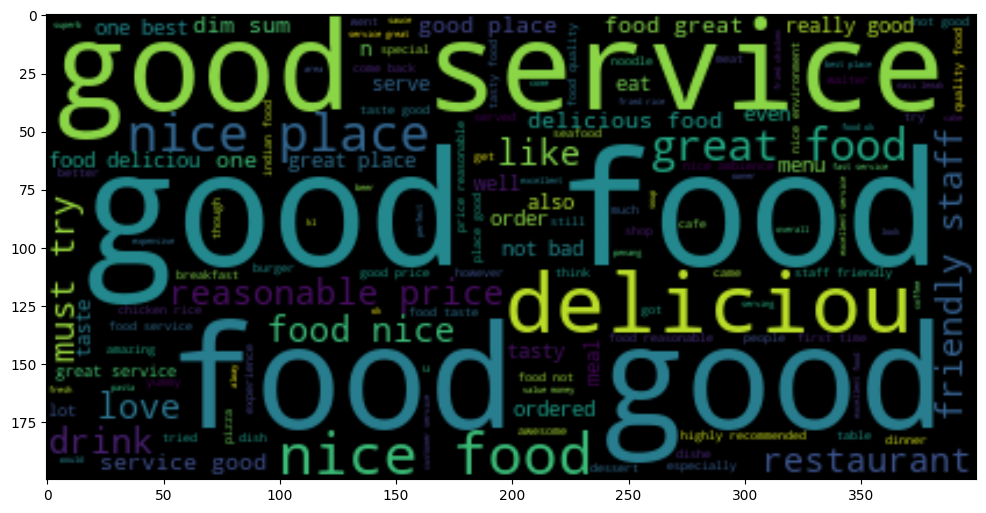

In [91]:
# overall
wordcloudz = WordCloud(stopwords=set(bilingual_stopwords)).generate(" ".join(tokens))

plt.figure(figsize = (12,8))
plt.imshow(wordcloudz, interpolation='bilinear');

## Unigram

### split dataset

In [92]:
df_ori.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222020 entries, 0 to 222019
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Author      222020 non-null  object
 1   Rating      222020 non-null  int64 
 2   Review      222020 non-null  object
 3   Restaurant  222020 non-null  object
 4   Location    222020 non-null  object
 5   Label       222020 non-null  object
 6   Word_count  222020 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 11.9+ MB


In [93]:
# from sklearn.model_selection import train_test_split

# #Separate the final Test Set (20%)
# df_temp, df_test = train_test_split(
#     df_ori, 
#     test_size=0.20,         
#     random_state=42, 
#     stratify=df_ori['Label'] # Keeps class balance stable
# )

# #Split the 80% temporary pool into Train (60%) and Val (20%) ---
# df_train, df_val = train_test_split(
#     df_temp, 
#     test_size=0.25,          
#     random_state=42, 
#     stratify=df_temp['Label']
# )

# # --- VERIFY THE SPLITS ---
# print(f"Total Rows in Dataset: {len(review_df)}")
# print(f"Training Set (60%):   {len(df_train)} rows")
# print(f"Validation Set (20%): {len(df_val)} rows")
# print(f"Testing Set (20%):    {len(df_test)} rows")

# print("\nVerify Stratification (Should be nearly identical percentages):")
# print("Train:\n", df_train['Label'].value_counts(normalize=True))
# print("Val:\n", df_val['Label'].value_counts(normalize=True))
# print("Test:\n", df_test['Label'].value_counts(normalize=True))

In [94]:
import os
import pandas as pd

# Read raw data
master_dir = os.path.dirname(os.getcwd())

# train dataset file
file_train_dataset = os.path.join(master_dir, "txsa part b",
                            "dataset",
                           "train_dataset_bilingual.csv")

df_train_bilingual = pd.read_csv(file_train_dataset)

In [95]:
df_train_bilingual = df_train_bilingual.drop(columns="Language")

In [96]:
# df of each category
df_train_positive = df_train_bilingual[df_train_bilingual["Rating"] > 3]
df_train_neutral = df_train_bilingual[df_train_bilingual["Rating"] == 3]
df_train_negative = df_train_bilingual[df_train_bilingual["Rating"] < 3]

### Positive Review

In [97]:
texts_positive = " ".join(review.lower() for review in df_train_positive["Review"])
# remove punctuation
tokenizer_positive = nltk.RegexpTokenizer(r"\w+")
tokens_positive = tokenizer.tokenize(texts_positive)
# remove stopwords
tokens_positive = [token for token in tokens_positive if token not in bilingual_stopwords]

positive_unigram = nltk.FreqDist(tokens_positive).most_common(20)

In [98]:
# top positive unigram
positiveUnigram_df = pd.DataFrame(positive_unigram, columns=['Unigram', 'Count'])
positiveUnigram_df

,Unigram,Count
0,makanan,41822
1,nice,21258
2,sedap,19114
3,ringan,18380
4,food,14119
5,baik,13862
6,delicious,12813
7,good,10824
8,tempat,6840
9,harga,6505


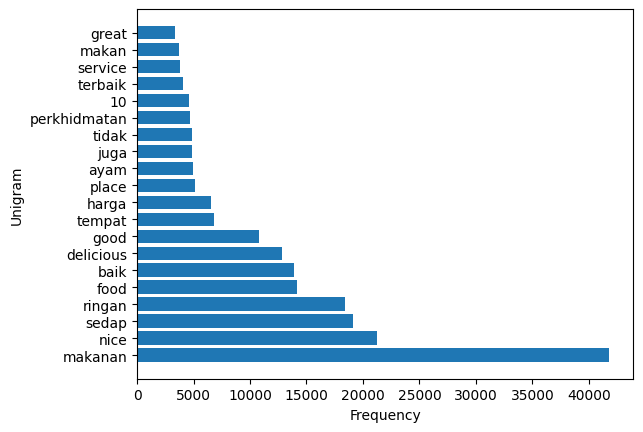

In [99]:
#positive review word distribution
plt.barh(positiveUnigram_df['Unigram'], width=positiveUnigram_df["Count"]);
plt.xlabel('Frequency');
plt.ylabel('Unigram');

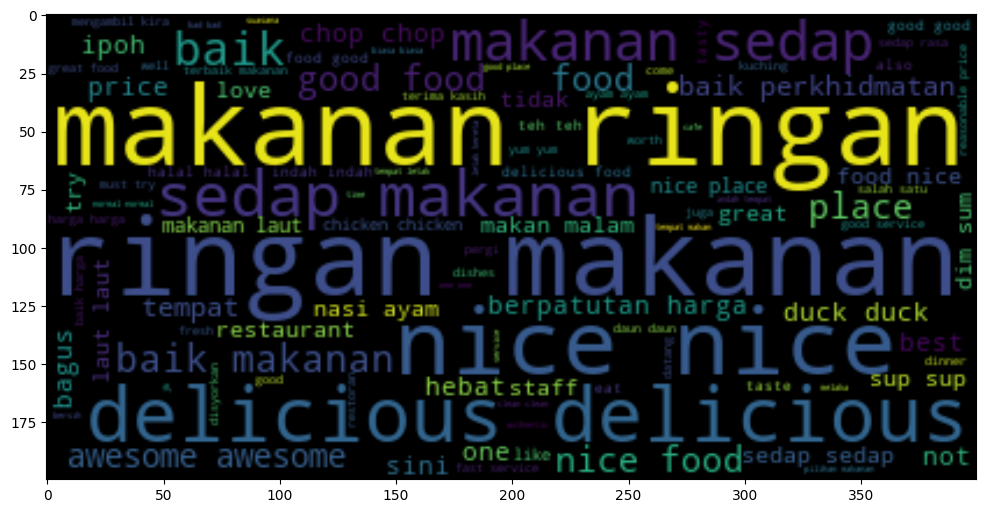

In [100]:
# positive review wordcloud
wordcloudz_positive = WordCloud(stopwords=set(bilingual_stopwords)).generate(texts_positive)
plt.figure(figsize = (12,8))
plt.imshow(wordcloudz_positive, interpolation='bilinear');

### Neutral Review

In [101]:
# neutral
texts_neutral = " ".join(review.lower() for review in df_train_neutral["Review"])
# remove punctuation
tokenizer_neutral = nltk.RegexpTokenizer(r"\w+")
tokens_neutral = tokenizer.tokenize(texts_neutral)
# remove stopwords
tokens_neutral = [token for token in tokens_neutral if token not in bilingual_stopwords]

neutral_unigram = nltk.FreqDist(tokens_neutral).most_common(20)

In [102]:
# Top neutral unigram
neutralUnigram_df = pd.DataFrame(neutral_unigram, columns=['Unigram', 'Count'])
neutralUnigram_df

,Unigram,Count
0,makanan,4033
1,nice,2987
2,tidak,2090
3,baik,1968
4,food,1848
5,sedap,1788
6,ringan,1339
7,good,1159
8,not,1123
9,tempat,1004


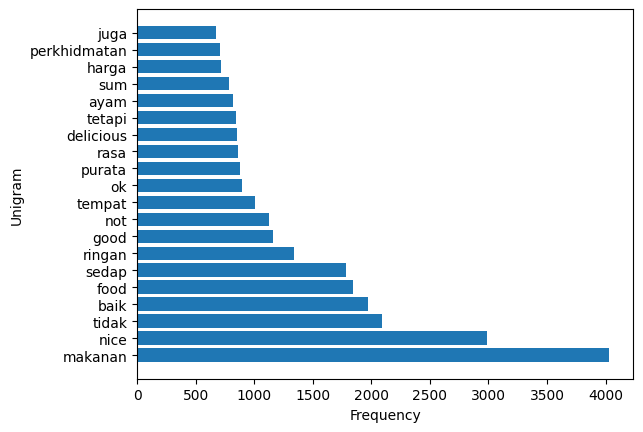

In [103]:
plt.barh(neutralUnigram_df['Unigram'], width=neutralUnigram_df["Count"]);
plt.xlabel('Frequency');
plt.ylabel('Unigram');

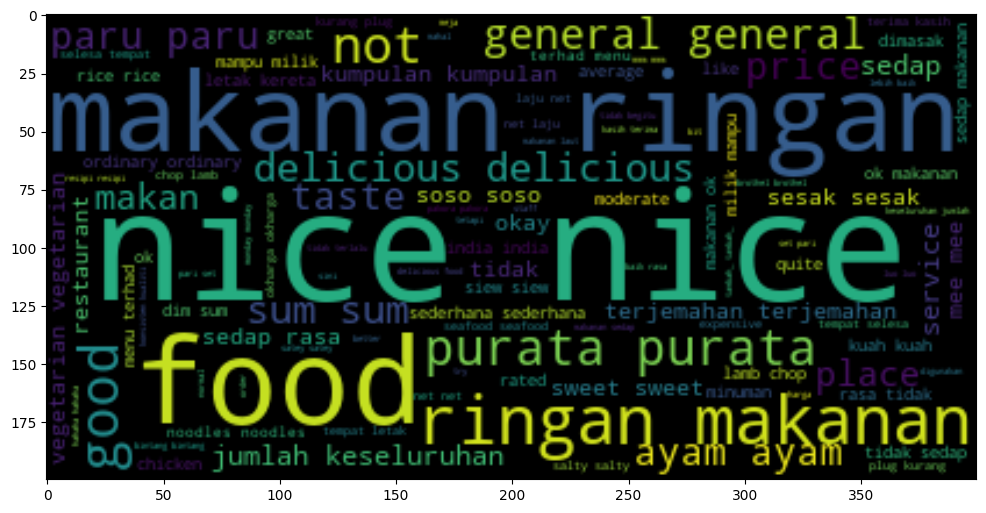

In [104]:
wordcloudz_neutral = WordCloud(stopwords=set(bilingual_stopwords)).generate(texts_neutral)
plt.figure(figsize = (12,8))
plt.imshow(wordcloudz_neutral, interpolation='bilinear');

### Negative Review

In [105]:
# negative
texts_negative = " ".join(review.lower() for review in df_train_negative["Review"])
# remove punctuation
tokenizer_negative = nltk.RegexpTokenizer(r"\w+")
tokens_negative = tokenizer.tokenize(texts_negative)

# remove stopwords
tokens_negative = [token for token in tokens_negative if token not in bilingual_stopwords]

negative_unigram = nltk.FreqDist(tokens_negative).most_common(20)

In [106]:
negativeUnigram_df = pd.DataFrame(negative_unigram, columns=['Unigram', 'Count'])
negativeUnigram_df

,Unigram,Count
0,tidak,3814
1,makanan,2636
2,not,1603
3,food,1534
4,baik,1438
5,sedap,1040
6,bad,1017
7,kopi,919
8,service,902
9,mahal,896


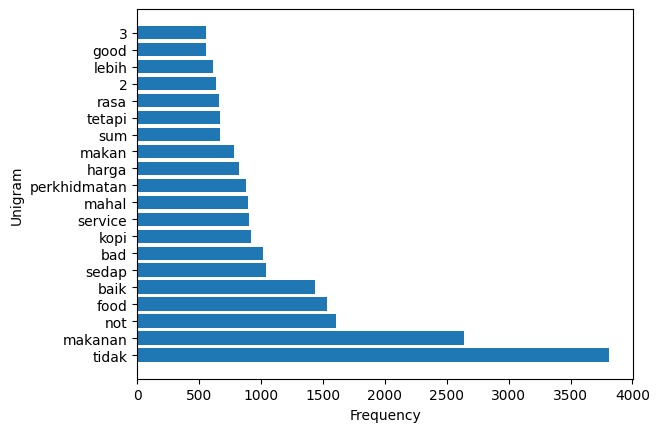

In [107]:
plt.barh(negativeUnigram_df['Unigram'], width=negativeUnigram_df["Count"]);
plt.xlabel('Frequency');
plt.ylabel('Unigram');

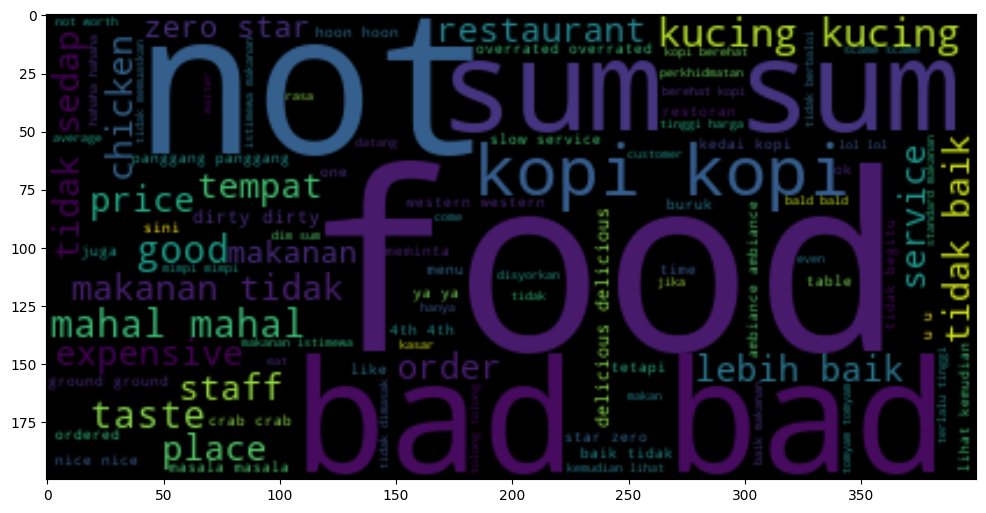

In [108]:
wordcloudz_negative = WordCloud(stopwords=set(bilingual_stopwords)).generate(texts_negative)
plt.figure(figsize = (12,8))
plt.imshow(wordcloudz_negative, interpolation='bilinear');

### combination of unigram for 3 sentiments

In [109]:
# breakdown by each sentiment
unigram_combined_df_each = pd.concat([
    positiveUnigram_df.rename(columns={'Unigram': 'Positive'})['Positive'],
    neutralUnigram_df.rename(columns={'Unigram': 'Neutral'})['Neutral'],
    negativeUnigram_df.rename(columns={'Unigram': 'Negative'})['Negative']
    ], axis=1).head(10)
unigram_combined_df_each

,Positive,Neutral,Negative
0,makanan,makanan,tidak
1,nice,nice,makanan
2,sedap,tidak,not
3,ringan,baik,food
4,food,food,baik
5,baik,sedap,sedap
6,delicious,ringan,bad
7,good,good,kopi
8,tempat,not,service
9,harga,tempat,mahal


In [110]:
# overall
unigram_combined_df = pd.concat([
    positiveUnigram_df,
    neutralUnigram_df,
    negativeUnigram_df
], axis=0).head(10)
unigram_combined_df

,Unigram,Count
0,makanan,41822
1,nice,21258
2,sedap,19114
3,ringan,18380
4,food,14119
5,baik,13862
6,delicious,12813
7,good,10824
8,tempat,6840
9,harga,6505


It could be observed that, the top common attributes are **food/makanan, nice/baik, sedap/delicious**

## Bigram

In [111]:
from sklearn.feature_extraction.text import CountVectorizer

# bigram vectorizer
vect = CountVectorizer(stop_words=bilingual_stopwords, ngram_range=(2, 2), max_features=1000)

### Positive Review

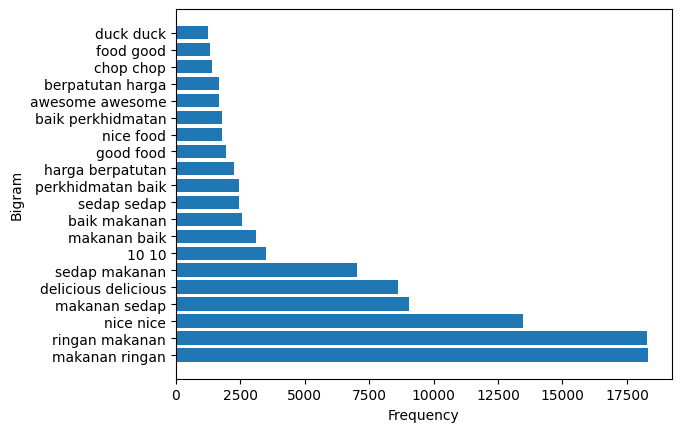

In [112]:
# Positive reviews
vect = CountVectorizer(
    ngram_range=(2, 2),          # Restricts vectorization strictly to bigrams
    stop_words=bilingual_stopwords, 
    token_pattern=r'\b\w+\b'     # Ensures local short words/slang are captured cleanly
)

bigrams_positive = vect.fit_transform(df_train_positive['Review'].astype(str))

frequencies = bigrams_positive.sum(axis=0).A1
vocab = vect.get_feature_names_out()

bigram_frequency = pd.DataFrame({'bigram': vocab, 'frequency': frequencies})
bigram_frequency = bigram_frequency.sort_values(by='frequency', ascending=False).head(20)

bigram_frequency.columns = ['bigram', 'frequency']
bigram_frequency = bigram_frequency.sort_values(
    by='frequency', ascending=False).head(20)

plt.barh(bigram_frequency["bigram"], width=bigram_frequency["frequency"]);
plt.xlabel('Frequency');
plt.ylabel('Bigram');

The most frequent positive bigrams revolve heavily around snacks/light meals ("makanan ringan"), food quality ("makanan sedap", "sedap makanan", "good food", "nice food"), and value ("harga berpatutan", "berpatutan harga").

### Negative Review

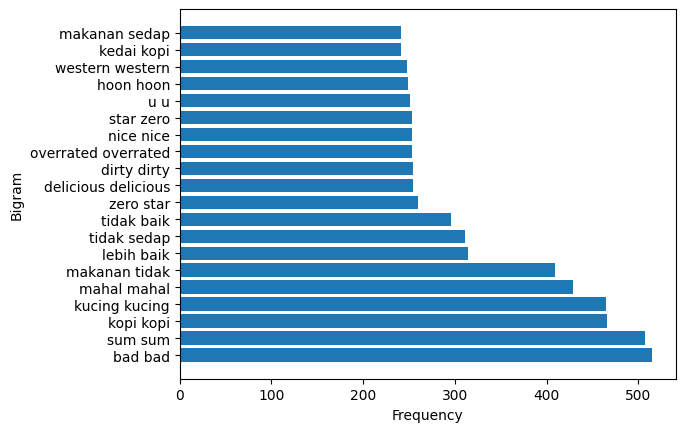

In [113]:
# Negative review
bigrams_negative = vect.fit_transform(df_train_negative['Review'].astype(str))

frequencies = bigrams_negative.sum(axis=0).A1
vocab = vect.get_feature_names_out()

bigram_frequency = pd.DataFrame({'bigram': vocab, 'frequency': frequencies})
bigram_frequency = bigram_frequency.sort_values(by='frequency', ascending=False).head(20)

bigram_frequency.columns = ['bigram', 'frequency']
bigram_frequency = bigram_frequency.sort_values(
    by='frequency', ascending=False).head(20)

plt.barh(bigram_frequency["bigram"], width=bigram_frequency["frequency"]);
plt.xlabel('Frequency');
plt.ylabel('Bigram');

The negative bigrams clearly highlight dissatisfaction with price ("mahal mahal" — expensive), quality ("bad bad", "dirty dirty", "overrated overrated"), and rating disappointment ("zero star", "star zero").

### Neutral Review

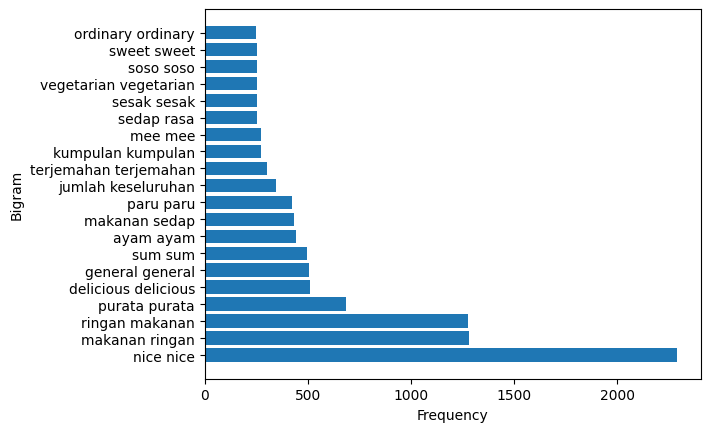

In [114]:
# Neutral reviews
bigrams_neutral = vect.fit_transform(df_train_neutral['Review'].astype(str))

frequencies = bigrams_neutral.sum(axis=0).A1
vocab = vect.get_feature_names_out()

bigram_frequency = pd.DataFrame({'bigram': vocab, 'frequency': frequencies})
bigram_frequency = bigram_frequency.sort_values(by='frequency', ascending=False).head(20)

bigram_frequency.columns = ['bigram', 'frequency']
bigram_frequency = bigram_frequency.sort_values(
    by='frequency', ascending=False).head(20)

plt.barh(bigram_frequency["bigram"], width=bigram_frequency["frequency"]);
plt.xlabel('Frequency');
plt.ylabel('Bigram');

Neutral reviews frequently feature moderate descriptors like "soso soso" (so-so) and "purata purata" (average), alongside specific food items ("ayam ayam", "paru paru", "mee mee").

## Trigram

In [115]:
# Trigram vectorizer
vect = CountVectorizer(stop_words=bilingual_stopwords, ngram_range=(3, 3), max_features=1000)

### Positive Review

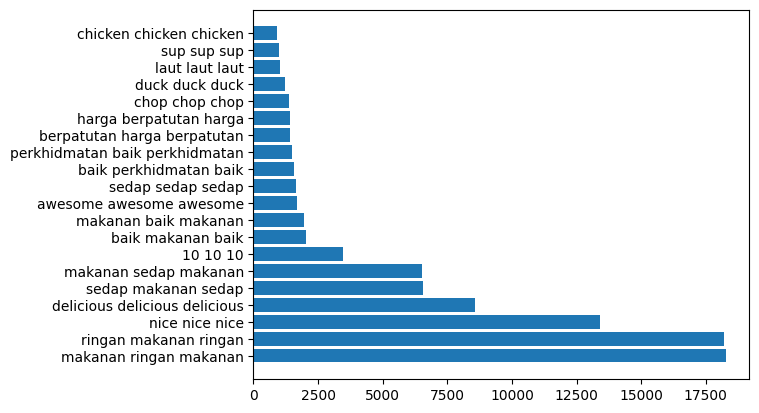

In [116]:
# Positive reviews

trigram_positive = vect.fit_transform(df_train_positive['Review'])
trigram_positive_df = pd.DataFrame(
    trigram_positive.toarray(), columns=vect.get_feature_names_out())

trigram_frequency = pd.DataFrame(trigram_positive_df.sum(axis=0)).reset_index()
trigram_frequency.columns = ['trigram', 'frequency']
trigram_frequency = trigram_frequency.sort_values(
    by='frequency', ascending=False).head(20)

plt.barh(trigram_frequency["trigram"], width=trigram_frequency["frequency"]);

The most dominant trigrams in positive reviews heavily feature snacks/light meals ("makanan ringan makanan") and praise for food taste ("makanan sedap makanan", "sedap makanan sedap", "delicious delicious delicious", "nice nice nice").  

Positive sentiment is also strongly tied to reasonable pricing ("harga berpatutan harga", "berpatutan harga berpatutan") and excellent customer service ("perkhidmatan baik perkhidmatan", "baik perkhidmatan baik").   

The appearance of "10 10 10" (~3,500) indicates that satisfied customers frequently use perfect numerical ratings (e.g., "10/10/10") to express enthusiasm.

### Neutral Review

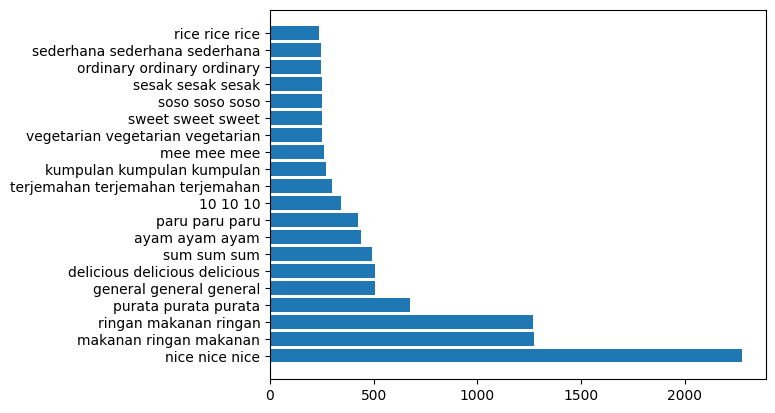

In [117]:
# neutral reviews

trigram_neutral = vect.fit_transform(df_train_neutral['Review'])
trigram_neutral_df = pd.DataFrame(
    trigram_neutral.toarray(), columns=vect.get_feature_names_out())

trigram_frequency = pd.DataFrame(trigram_neutral_df.sum(axis=0)).reset_index()
trigram_frequency.columns = ['trigram', 'frequency']
trigram_frequency = trigram_frequency.sort_values(
    by='frequency', ascending=False).head(20)

plt.barh(trigram_frequency["trigram"], width=trigram_frequency["frequency"]);

Neutral reviews prominently display moderate terms like "purata purata purata" (average) and "soso soso soso" (so-so), as well as generic descriptions like "general general general" and "ordinary ordinary ordinary".  

Phrases such as "nice nice nice", "makanan ringan makanan", and "delicious delicious delicious" appear in neutral reviews because 3-star reviews frequently combine mixed praise and criticism (e.g., "The food was nice nice nice, but the wait time was very long").

Neutral feedback often consists of plain mentions of food items without explicit sentiment, such as "ayam ayam ayam" (chicken), "paru paru paru" (beef lung), and "mee mee mee" (noodles). 

### Negative Review

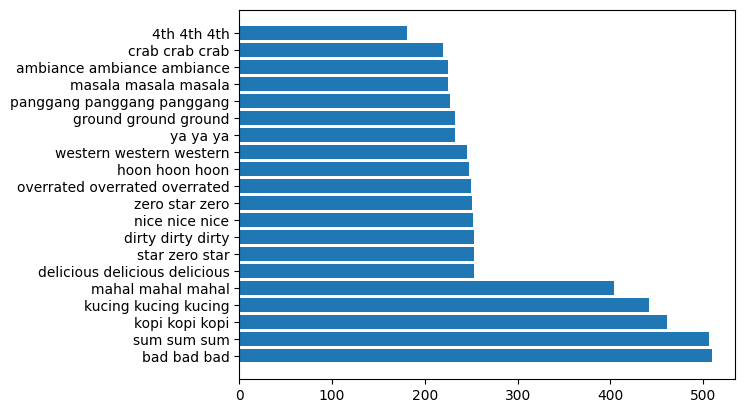

In [118]:
# negative reviews

trigram_negative = vect.fit_transform(df_train_negative['Review'])
trigram_negative_df = pd.DataFrame(
    trigram_negative.toarray(), columns=vect.get_feature_names_out())

trigram_frequency = pd.DataFrame(trigram_negative_df.sum(axis=0)).reset_index()
trigram_frequency.columns = ['trigram', 'frequency']
trigram_frequency = trigram_frequency.sort_values(
    by='frequency', ascending=False).head(20)

plt.barh(trigram_frequency["trigram"], width=trigram_frequency["frequency"]);

Negative trigrams focus heavily on cost ("mahal mahal mahal" — expensive), hygiene/quality ("bad bad bad", "dirty dirty dirty", "overrated overrated overrated"), and bad ratings ("zero star zero", "star zero star").  

Phrases like "kopi kopi kopi" (coffee) and "kucing kucing kucing" (cats) point to specific complaints regarding beverage quality or stray animals near outdoor dining areas. Food items like "crab crab crab", "masala masala masala", and "western western western" highlight specific dishes associated with customer dissatisfaction.



## POS Tagging

## Lexicon Polarity